# Perturb-seq Top-5000 HVG (Batch-Removed) to HiPoNet Point Clouds

This notebook builds HiPoNet point clouds from `subset_top_5000_hvg_batch_rm.h5ad`.
It uses PCA features from this dataset to create compact point-cloud representations for each perturbation group.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import scanpy as sc
from scipy.sparse import issparse

In [2]:
# Resolve project paths robustly whether the notebook is launched from the repo root or perturb-seq/
CWD = Path.cwd().resolve()
if (CWD / "unsupervised_main.py").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "unsupervised_main.py").exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

DATA_PATH = PROJECT_ROOT / "perturb-seq" / "subset_top_5000_hvg_batch_rm.h5ad"
OUT_DIR = PROJECT_ROOT / "perturb-seq"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Loading: {DATA_PATH}")
adata = sc.read_h5ad(DATA_PATH)
print(adata)

# Ensure PCA features exist on adata.obsm['X_pca'] for point-cloud construction.
if "X_pca" not in adata.obsm:
    target_pcs = min(64, adata.n_vars, max(2, adata.n_obs - 1))
    print(f"Computing PCA with n_comps={target_pcs}...")
    sc.pp.pca(adata, n_comps=target_pcs)
else:
    print(f"Using existing PCA features with shape: {adata.obsm['X_pca'].shape}")

Project root: /nfs/roberts/project/pi_sk2433/sv496/HiPoNet
Loading: /nfs/roberts/project/pi_sk2433/sv496/HiPoNet/perturb-seq/subset_top_5000_hvg_batch_rm.h5ad
AnnData object with n_obs × n_vars = 214449 × 5000
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'perturbed_gene', 'perturbation_barcode', 'cell_barcode', 'experiment', 'batch_name'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 

In [3]:
print("obs columns:")
print(list(adata.obs.columns))
print()
print("obsm keys:")
print(list(adata.obsm.keys()))

display(adata.obs.head())

obs columns:
['batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'perturbed_gene', 'perturbation_barcode', 'cell_barcode', 'experiment', 'batch_name']

obsm keys:
['X_pca', 'X_phate_2D', 'X_phate_2D_PCA', 'X_phate_3D', 'X_umap']


,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,perturbed_gene,perturbation_barcode,cell_barcode,experiment,batch_name
JAG1:GATGCGCCCTGCCCGGCGTGC:AAACCCACAATCGCAT-scRNAseq_2kG_11AMDox_1-treatment,0,4528,8.418256,21486.0,9.975204,33.468305,45.773992,55.668808,67.406683,2345.0,...,8.620652,25.802847,0.0,0.0,0.0,JAG1,GATGCGCCCTGCCCGGCGTGC,AAACCCACAATCGCAT,treatment,scRNAseq_2kG_11AMDox_1
AGAP2:GAAGTGAGGTCGACAGACGGA:AAACCCATCTCCGAAA-scRNAseq_2kG_11AMDox_1-treatment,0,3883,8.264621,15760.0,9.665294,31.453046,44.035533,54.517766,66.865482,1431.0,...,8.316789,25.958120,0.0,0.0,0.0,AGAP2,GAAGTGAGGTCGACAGACGGA,AAACCCATCTCCGAAA,treatment,scRNAseq_2kG_11AMDox_1
PCMTD2:GCCGCGGGCCTGGCACTTAAA:AAAGGTAAGGCACAAC-scRNAseq_2kG_11AMDox_1-treatment,0,3037,8.018955,11171.0,9.321166,31.304270,44.624474,55.939486,69.232835,919.0,...,8.063377,28.421806,0.0,0.0,0.0,PCMTD2,GCCGCGGGCCTGGCACTTAAA,AAAGGTAAGGCACAAC,treatment,scRNAseq_2kG_11AMDox_1
PLEKHH3:GCCCCGGGACTGGCGCGCTG:AAAGTCCAGGTGATAT-scRNAseq_2kG_11AMDox_1-treatment,0,3497,8.159947,13190.0,9.487290,31.152388,45.102350,55.799848,67.680061,694.0,...,8.339501,31.728584,0.0,0.0,0.0,PLEKHH3,GCCCCGGGACTGGCGCGCTG,AAAGTCCAGGTGATAT,treatment,scRNAseq_2kG_11AMDox_1
CHCHD10:GCCACCGCCGCCACCATGCCT:AACAAAGCAGCGCGTT-scRNAseq_2kG_11AMDox_1-treatment,0,3789,8.240121,14981.0,9.614605,29.857820,42.360323,52.646686,65.803351,1268.0,...,8.272315,26.119751,0.0,0.0,0.0,CHCHD10,GCCACCGCCGCCACCATGCCT,AACAAAGCAGCGCGTT,treatment,scRNAseq_2kG_11AMDox_1


In [4]:
candidate_groupings = [
    ["perturbed_gene"],
    ["perturbed_gene", "batch_name"],
    ["perturbed_gene", "experiment"],
]

for cols in candidate_groupings:
    if all(col in adata.obs.columns for col in cols):
        n_groups = adata.obs.groupby(cols, observed=True).ngroups
        print(f"Grouping {cols} -> {n_groups} populations")
    else:
        print(f"Grouping {cols} skipped (missing columns)")

Grouping ['perturbed_gene'] -> 2620 populations
Grouping ['perturbed_gene', 'batch_name'] -> 49265 populations
Grouping ['perturbed_gene', 'experiment'] -> 5164 populations


In [5]:
# Defaults tuned for the large preprocessed dataset
GROUP_BY = ["perturbed_gene"]
FEATURE_SOURCE = "X_pca"  # recommended: use PCA features instead of raw X
N_COMPONENTS = 64         # try 64 first; 32 or 100 are also reasonable
MIN_CELLS_PER_POP = 0
MAX_CELLS_PER_POP = None
RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

In [6]:
def resolve_feature_matrix(adata, feature_source, n_components=None):
    if feature_source == "X":
        X = adata.X
        if issparse(X):
            X = X.toarray()
        X = np.asarray(X, dtype=np.float32)
        feature_names = [f"gene_{i}" for i in range(X.shape[1])]
        return X, feature_names

    if feature_source == "X_pca":
        if "X_pca" not in adata.obsm:
            raise ValueError("adata.obsm['X_pca'] is missing")
        X = np.asarray(adata.obsm["X_pca"], dtype=np.float32)
        if n_components is not None:
            X = X[:, :n_components]
        feature_names = [f"PC{i + 1}" for i in range(X.shape[1])]
        return X, feature_names

    raise ValueError(f"Unsupported FEATURE_SOURCE: {feature_source}")


def summarize_metadata(values):
    unique_values = pd.Series(values).astype(str).value_counts()
    if len(unique_values) == 1:
        return unique_values.index[0]
    return "mixed"


def build_populations_from_matrix(adata, feature_matrix, group_by, min_cells=20, max_cells=None, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    grouped = adata.obs.groupby(group_by, observed=True).indices
    populations = []
    labels = []
    group_names = []
    sizes = []
    experiment_values = []
    batch_values = []

    for label_idx, (group_key, row_idx) in enumerate(grouped.items()):
        idx = np.asarray(row_idx)
        if idx.size < min_cells:
            continue

        if max_cells is not None and idx.size > max_cells:
            idx = rng.choice(idx, size=max_cells, replace=False)

        Xg = np.asarray(feature_matrix[idx], dtype=np.float32)
        populations.append(Xg)
        labels.append(label_idx)

        if isinstance(group_key, tuple):
            group_name = "__".join(map(str, group_key))
        else:
            group_name = str(group_key)
        group_names.append(group_name)
        sizes.append(Xg.shape[0])

        if "experiment" in adata.obs.columns:
            experiment_values.append(summarize_metadata(adata.obs.iloc[idx]["experiment"]))
        if "batch_name" in adata.obs.columns:
            batch_values.append(summarize_metadata(adata.obs.iloc[idx]["batch_name"]))

    if not populations:
        raise ValueError("No populations survived filtering. Lower MIN_CELLS_PER_POP or adjust GROUP_BY.")

    payload = {
        "populations": populations,
        "labels": np.asarray(labels),
        "num_labels": np.unique(labels).size,
        "group_keys": np.asarray(group_by, dtype=object),
        "group_names": np.asarray(group_names, dtype=object),
        "population_sizes": np.asarray(sizes),
    }
    if experiment_values:
        payload["experiment"] = np.asarray(experiment_values, dtype=object)
    if batch_values:
        payload["batch_name"] = np.asarray(batch_values, dtype=object)
    return payload

In [7]:
feature_matrix, feature_names = resolve_feature_matrix(
    adata,
    FEATURE_SOURCE,
    n_components=N_COMPONENTS if FEATURE_SOURCE == "X_pca" else None,
)

payload = build_populations_from_matrix(
    adata=adata,
    feature_matrix=feature_matrix,
    group_by=GROUP_BY,
    min_cells=MIN_CELLS_PER_POP,
    max_cells=MAX_CELLS_PER_POP,
    rng=rng,
)

pop_sizes = payload["population_sizes"]
print(f"Number of populations (point clouds): {len(payload['populations'])}")
print(f"Feature source: {FEATURE_SOURCE}")
print(f"Feature dimension per point: {payload['populations'][0].shape[1]}")
print(f"Population size stats: min={pop_sizes.min()}, median={np.median(pop_sizes):.1f}, max={pop_sizes.max()}")

preview = pd.DataFrame({
    "group_name": payload["group_names"][:10],
    "n_cells": pop_sizes[:10],
})
if "experiment" in payload:
    preview["experiment"] = payload["experiment"][:10]
if "batch_name" in payload:
    preview["batch_name"] = payload["batch_name"][:10]
display(preview)

Number of populations (point clouds): 2620
Feature source: X_pca
Feature dimension per point: 50
Population size stats: min=2, median=82.0, max=3284


,group_name,n_cells,experiment,batch_name
0,9p21-add-AL354709-1,21,mixed,mixed
1,9p21-add-AL359922-2,74,mixed,mixed
2,9p21-add-AL359922-3,2,control,mixed
3,9p21-add-AL449423-1,73,mixed,mixed
4,9p21-add-CDKN2A-DT,17,control,mixed
5,9p21-add-CDKN2A-alt-TSS,68,mixed,mixed
6,AACS,86,mixed,mixed
7,AAGAB,103,mixed,mixed
8,AAMP,69,mixed,mixed
9,ABCA5,120,mixed,mixed


In [10]:
pop_sizes = payload["population_sizes"]
group_names = payload["group_names"]
summary = pd.Series(pop_sizes).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
display(summary.to_frame(name="n_cells"))

smallest_idx = int(np.argmin(pop_sizes))
largest_idx = int(np.argmax(pop_sizes))
smallest = {
    "group_name": group_names[smallest_idx],
    "n_cells": int(pop_sizes[smallest_idx]),
}
largest = {
    "group_name": group_names[largest_idx],
    "n_cells": int(pop_sizes[largest_idx]),
}
if "experiment" in payload:
    smallest["experiment"] = payload["experiment"][smallest_idx]
    largest["experiment"] = payload["experiment"][largest_idx]
if "batch_name" in payload:
    smallest["batch_name"] = payload["batch_name"][smallest_idx]
    largest["batch_name"] = payload["batch_name"][largest_idx]

display(pd.DataFrame([smallest, largest], index=["smallest", "largest"]))

,n_cells
count,2620.000000
mean,81.850763
std,79.021006
min,2.000000
10%,48.000000
25%,68.000000
50%,82.000000
75%,95.000000
90%,107.000000
95%,114.000000


,group_name,n_cells,experiment,batch_name
smallest,9p21-add-AL359922-3,2,control,mixed
largest,safe-targeting,3284,mixed,mixed


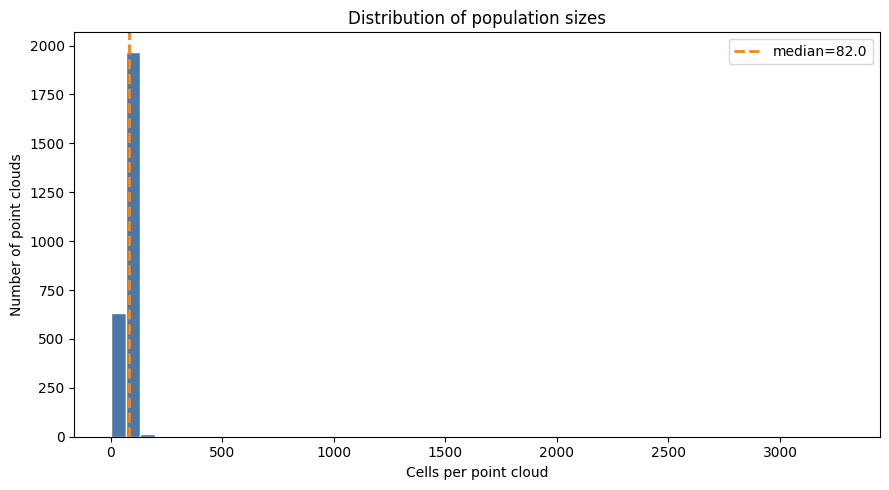

In [11]:
plt.figure(figsize=(9, 5))
plt.hist(pop_sizes, bins=50, color="#4C78A8", edgecolor="white")
plt.axvline(np.median(pop_sizes), color="#F58518", linestyle="--", linewidth=2, label=f"median={np.median(pop_sizes):.1f}")
plt.xlabel("Cells per point cloud")
plt.ylabel("Number of point clouds")
plt.title("Distribution of population sizes")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
dataset_tag = DATA_PATH.stem
cache_path = OUT_DIR / f"perturbseq_populations_{dataset_tag}_{FEATURE_SOURCE.lower()}_{payload['populations'][0].shape[1]}d.pkl"
payload["feature_source"] = FEATURE_SOURCE
payload["feature_names"] = np.asarray(feature_names, dtype=object)
payload["n_components"] = payload['populations'][0].shape[1]
payload["source_h5ad"] = str(DATA_PATH)

with open(cache_path, "wb") as handle:
    pickle.dump(payload, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved population cache: {cache_path}")

Saved population cache: /nfs/roberts/project/pi_sk2433/sv496/HiPoNet/perturb-seq/perturbseq_populations_subset_top_5000_hvg_batch_rm_x_pca_50d.pkl


In [9]:
with open(cache_path, "rb") as handle:
    loaded = pickle.load(handle)

print("keys:", sorted(loaded.keys()))
print("n point clouds:", len(loaded["populations"]))
print("first cloud shape:", loaded["populations"][0].shape)
print("group keys:", loaded["group_keys"])
print("feature source:", loaded["feature_source"])

keys: ['batch_name', 'experiment', 'feature_names', 'feature_source', 'group_keys', 'group_names', 'labels', 'n_components', 'num_labels', 'population_sizes', 'populations', 'source_h5ad']
n point clouds: 2620
first cloud shape: (21, 50)
group keys: ['perturbed_gene']
feature source: X_pca


## Next step

Example command from the repo root:

uv run python unsupervised_main.py --raw_dir population_npz --population_cache perturb-seq/perturbseq_populations_subset_top_5000_hvg_batch_rm_x_pca_50d.pkl --save_dir checkpoints/perturbseq_preprocessed_pca50 --latent_dim 32 --num_epochs 80 --batch_size 2 --dist_weight 0 --phate_color_by experiment --disable_wb